<div style="display:none">
$$
\def\rvar#1{\mathrm{#1}}
\def\rvec#1{\mathbf{#1}}
\def\vec#1{\boldsymbol{#1}}
\def\tens#1{\boldsymbol{\mathsf{#1}}}
\def\tensel#1{\mathsf{#1}}
\def\st#1{\mathcal{#1}}
\def\diag#1{\mathrm{diag}(\vec{#1})}
$$
</div>

In [2]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/03_DL
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline
dev = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

import nns.helpers as hp

<IPython.core.display.Latex object>

# Connectionist models

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/neuron.jpg" width="40%"/>
</center>
<p style="text-align:right">Copyright [AI:MA]</p>

+ Human neuron switching time ~$.001$ second
+ Number of neurons ~$10^{10}$
+ Connections per neuron ~$10^{4-5}$
+ Scene recognition time ~$.1$ second
+ 100 inference steps doesn't seem like enough
+ [$\rightarrow$] much parallel computation

# Artificial neural networks

## Properties of Artificial Neural Nets (ANN's)

- Many neuron-like threshold switching units
- Many weighted interconnections among units
- Highly parallel, distributed processing
- Emphasis on automatic feature selection 

## When to consider ANNs
- Input is high-dimensional discrete or real-valued (e.g. raw sensor input)
- Output is discrete or real valued
- Output is a vector of values
- Possibly noisy data
- Form of the target function is unknown 
- Human-readability/explainability of a model/results is unimportant

# Perceptron

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-perceptron.jpg" width="50%"/>
</center>

- $w_0$ represents bias of the model - a threshold that the weighted combination of inputs should surpass in order for the perceptron to output a 1.
- The activation function is often called unit step function, Heaviside step function, or *hardlim*
- Often a vector notation is used, where $\vec{w}$ is a column and $\vec{x}$ is a row vector
$$\hat{y} = \left\{ \begin{array}{rl}
      1 & \mbox{if $\vec{x}\vec{w} > 0$}\\
     -1 & \mbox{otherwise}  
\end{array}
\right. $$
- or simply $\hat{y} = \mathit{hardlim}(\vec{x}\vec{w})$

## Training a Perceptron

- Given a set of examples $\vec{X}$, their labels $\vec{t}=[t_1, t_2, \dots, t_m]^\top$ and a learning rate $\eta \leq 1$

$$ \vec{X} = \left[ \begin{array}{cccc}
1 & x_{11} & \dots & x_{1n} \\
1 & x_{21} & \dots & x_{1n}  \\
\dots & \dots & \dots & \dots  \\
1 & x_{m1} & \dots & x_{mn} \\
\end{array} \right] 
=
\left[ \begin{array}{c}
\vec{x}_1  \\
\vec{x}_2 \\
\dots  \\
\vec{x}_m  \\
\end{array} \right]
$$

- Initialize the weight vector $\vec{w}$ with some small randomly generated values
- Present each example $\vec{x}_k \in \vec{X}$ to the network, i.e., compute a vector $\vec{\hat{y}} = [\hat{y}_1, \dots, \hat{y}_m]^\top$, where $\hat{y}_k = \mathit{hardlim}(\vec{x}_k\vec{w})$
    - Intuitively:
      - If the example is classified correctly, then $t_{k} - \hat{y}_k = 0$ and therefore no weights must be updated
      - Otherwise $t_{k} - \hat{y}_k = \pm 2$, therefore, each weight $w_i$ must be updated, i.e., increased/decreased by $\eta\:\sum_{k=0}^m x_{ki}$
- Update the weights:
$$\vec{w}_{new} = \vec{w}_{old} + \eta\; \Delta\vec{w} \quad\text{  where  }\quad \Delta\vec{w} = (\vec{t}-\vec{\hat{y}})\;\vec{X}$$
   - that is 
$$\Delta w_{i} = \sum_{\langle \vec{x}_k, t_k, \hat{y}_k \rangle \in \langle \vec{X}, \vec{t}, \vec{\hat{y}} \rangle} (t_{k} - \hat{y}_k) x_{ki}$$
where $x_{ki} \in \vec{x}_k$ is the observed value of an $i$-th feature in $k$-th example

In [3]:
class Perceptron:

    def __init__(self, h=0.01, epoch=1000, eps = 0.0001):
        self.h = h
        self.epoch = epoch
        self.eps = eps

    def _fit(self, X, labels):
        for i in range(self.epoch):
            # forward - compute predictions
            y_hat = self._predict(X)
            # compare labels - error vector
            err = torch.subtract(labels, y_hat)
            # termination criterion
            if (torch.norm(err) < self.eps): break
            # update the weights
            dw = torch.matmul(err, X).reshape(-1,1)
            self.w += self.h*dw

        print("Epoch {}: y_hat={}, err={}, w={}".format(i, y_hat, err, self.w.T))

    def _predict(self, X):
        return self.hardlim(torch.matmul(X, self.w)).flatten()
    
    def hardlim(self, x):
        out = torch.sign(x) # [-1, 0, 1]
        out[out == 0] = -1
        return out

    def fit(self, data, labels):
        # add bias to the data
        X = torch.cat((torch.ones((data.size()[0],1)), data), 1)
        # initialize weights
        self.w = torch.randn((X.size()[1],1))/math.sqrt(X.size()[0])
        self._fit(X, labels)

    def predict(self, X):
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X).float()
        if X.size()[1] < self.w.size()[0]:
            X = torch.cat((torch.ones((X.size()[0],1)), X), 1)
        return self._predict(X)

### Initialization of weights

- In the example above the weights were initialized by small random values
- This procedure has a huge impact on the training process
    - Too small values might make it unnecessary long (vanishing gradients) or underflows
    - Too large - may lead to overflows during computations

In [4]:
@interact(factor=(4,15,1))
def init_value(factor=5):
    y = torch.ones(100,100)
    for i in range(100):
        y = y @ (torch.randn(100,100)/factor) # matrix multiplication
    print("Mean: {}".format(y.mean()))

interactive(children=(IntSlider(value=5, description='factor', max=15, min=4), Output()), _dom_classes=('widge…

### Initialization of weights, cont'd

- How can we found the correct factor automatically?
- Multiplication of two $(n \times m)$ and $(m \times r)$ matrices requires the computation of $n\times r$ sums of $m$ products
- If we sample our matrices from a normal distribution $\mathcal{N}(0,1)$, then these $m$ products will also be distributed normally with $0$ mean and unit variance (standard deviation - $\sqrt{1}$)
- The sum will also have $0$ mean, but the variance is $m$ (standard deviation $\sqrt{m}$)
- We can rescale the values of a product matrix by the factor $1/\sqrt{m}$
    - Factor $10$ in the example above for $(100\times 100)$ matrices


Epoch 10: y_hat=tensor([-1.,  1., -1., -1.]), err=tensor([0., 0., 0., 0.]), w=tensor([[-0.1806,  0.1428,  0.0866]])


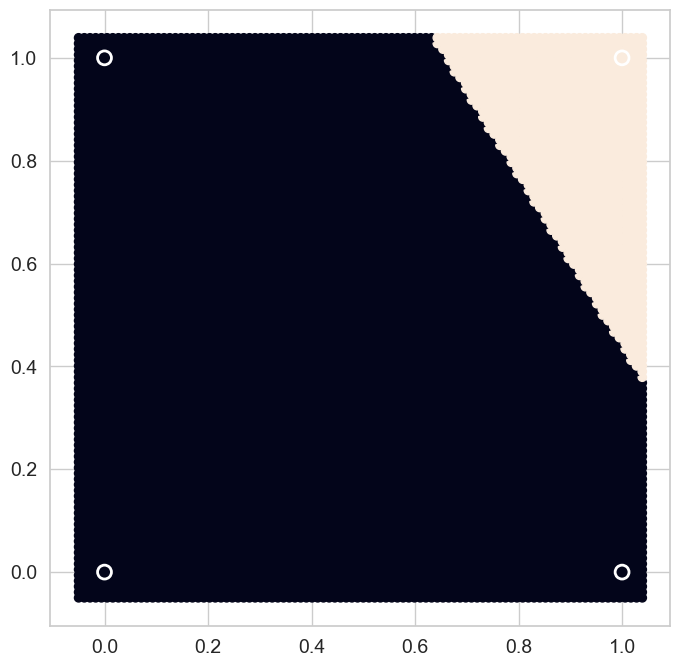

In [5]:
data = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
t = torch.tensor([-1., 1., -1., -1.])

p = Perceptron(epoch=100)
p.fit(data, t)

hp.plot_binary(p.predict, data, t)

## Decision surface of a perceptron

- Convergence is guaranteed if 
  - the training data is linearly separable, and
  - $\eta$ is sufficiently small, e.g., $\eta=0.1$
+ Decision surface of a two input ($x_1$ and $x_2$) perceptron: linearly (AND, OR, NAND) and non-linearly (XOR, EQ) separable
+ Perceptrons can represent linearly separable functions AND, OR, NAND, and NOR
+ Any Boolean function can be represented as a network of perceptrons

## Example - binary classification

In [6]:
@interact(fn=['and','or', 'xor'])
def perceptron(fn='and'):
    X = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
    y = hp.rescale(hp.switch_fn(fn)(X))

    # train a perceptron
    clf = Perceptron()
    clf.fit(X, y)
    hp.plot_binary(clf.predict, X, y)

interactive(children=(Dropdown(description='fn', options=('and', 'or', 'xor'), value='and'), Output()), _dom_c…

# Adaline

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-adaline.jpg" width="60%"/>
</center>

- ADAptive Linear Neuron (Adaline) was published only few years after Rosenblatt's perceptron
- Can be considered as improvement of the first one, because it allows a learner to determine "how much" it was right or wrong
- Known also as *delta* or *Widrow-Hoff rule* (after its inventors)

## Adaline training rule

- **Idea**: Use the same algorithm to update weights as for perceptron 
- However, instead of $\hat{y}$ we consider $s$ as an output
$$\vec{s}=\vec{X}\vec{w}$$
where
$$s_j = \vec{x}_j\vec{w} = \sum_{i=0}^n x_{ji}w_{i}$$
- The difference $\vec{e}=\vec{t} - \vec{s} = \vec{t} - \vec{X}\vec{w}$ is vector of a real values indicating the classification error for each example
- Let's find the weights $\vec{w}$ that **minimize** the *mean squared error* (MSE) **loss function**
$$ E[\vec{w}] \doteq \frac{1}{n} \vec{e}^T\vec{e} = \frac{1}{n}\sum_{\langle s_i, t_i \rangle \in \langle \vec{s}, \vec{t} \rangle}(t_{i} - s_{i})^{2} $$
where $\vec{t}$ is a set of labels, $\vec{s}$ is a set of predictions and $n$ is the number of observations
   - factor $1/2n$ is often used to simplify the math
- Use the *gradient descent* optimization method

## Gradient

+ Training rule for AdaLine: 
$$ \vec{w}_{new} \leftarrow \vec{w}_{old} + \eta\:\Delta\vec{w} \qquad\text{ where } \qquad\Delta \vec{w} = -\nabla E[\vec{w}] $$

$$ \nabla_w E[\vec{w}] = \nabla_w \frac{1}{2n} (\vec{t} - \vec{X}\vec{w})^\top(\vec{t} - \vec{X}\vec{w}) = \frac{1}{2n}(2\vec{X}^\top\vec{X}\vec{w} - 2\vec{X}^\top\vec{t})=$$ $$=\frac{1}{n}(\vec{X}^\top\vec{X}\vec{w} - \vec{X}^\top\vec{t})$$

+ That is, for every weight:

$$ \nabla E[\vec{w}] \doteq \left[\frac{\partial E}{\partial w_{0}},
\frac{\partial E}{\partial w_{1}}, \cdots, \frac{\partial E}{\partial
w_{n}}\right] $$


\begin{eqnarray*}
\frac{\partial E}{\partial w_{i}} 
& = & \frac{\partial}{\partial w_{i}} \frac{1}{2n}\sum_{k}(t_{k} - s_{k})^{2} = \frac{1}{2n}\sum_{k}\frac{\partial}{\partial w_{i}} (t_{k} - s_{k})^{2} 
 = \frac{1}{2n}\sum_{k} 2 (t_{k} - s_{k}) \frac{\partial}{\partial w_{i}}(t_{k} - \vec{x}_{k}\vec{w}) \\
& = & \frac{1}{n} \sum_{k} (t_{k} - s_{k}) \frac{\partial}{\partial w_{i}}(t_{k} - \sum_{j}{x}_{kj}{w_j}) = \frac{1}{n}\sum_{k} (t_{k} - s_{k}) (- x_{ki})
\end{eqnarray*}

In [7]:
class AdaLine(Perceptron):
    def __init__(self, h=0.01, epoch=1000, eps=0.0001):
        super().__init__(h=h, epoch=epoch, eps=eps)

    def _fit(self, X, labels):
        m = 0
        n=X.size()[0]
        for i in range(self.epoch):
            # compute the gradient
            grad = -(1/n)*torch.subtract(torch.linalg.multi_dot([X.T, X, self.w]), 
                                         torch.matmul(X.T, labels).reshape(-1, 1))
            # termination criterion
            if m > 0 and (m - torch.norm(grad)) < self.eps: break
            m = torch.norm(grad)
            self.w += self.h*grad

        print("Epoch {}: grad={}, w={}".format(i, grad.T, self.w.T))

In [8]:
@interact(fn=['and','or', 'xor'])
def perceptron(fn='and'):
    X = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
    y = hp.rescale(hp.switch_fn(fn)(X))

    # train a perceptron
    clf = AdaLine()
    clf.fit(X, y)
    hp.plot_binary(clf.predict, X, y)

interactive(children=(Dropdown(description='fn', options=('and', 'or', 'xor'), value='and'), Output()), _dom_c…

# Sigmoid unit

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid.jpg" width="50%"/>
</center>

+ $\sigma(x)$ is the sigmoid function (see the [Probability](../01_Introduction/02_probability.ipynb) notebook for a discussion of functions used in ANNs) $$ \sigma(x) = \frac{1}{1 + e^{-x}} $$
+ Nice property: $\frac{\partial \sigma}{\partial x} = \sigma(x) (1 - \sigma(x))$
+ We can derive gradient decent rules to train
    - One sigmoid unit
    - *Multilayer networks* of sigmoid units - end-to-end differentiable!

<div class="myalert">However, deriving such rules for arbitrary networks manually is tedious!</div>

## Idea of the backpropagation

- Consider a function $f(x,y) = \frac{1}{2}(x-y)^2$
- Given a substitution $q(x,y)=x-y$ it can be rewritten as $f(q) = \frac{1}{2}q^2$
- Differentiation of this function is done using the **chain rule**
\begin{equation*}
 \frac{\partial f}{\partial x} = \frac{\partial f}{\partial q}\frac{\partial q}{\partial x}
\end{equation*}
- $\frac{\partial f}{\partial q} = q$ and $\frac{\partial q}{\partial x} = 1$, thus $\frac{\partial f}{\partial x} = q = x-y$
- Similarly, $\frac{\partial q}{\partial y} = -1$, therefore, $\frac{\partial f}{\partial y} = -q = y-x$
- As earlier, partial derivatives of $f$ on $x$ and $y$ express the sensitivity of $f$ on these variables
- However, this influence is expressed over the partial derivative $\frac{\partial f}{\partial q}$ for an intermediate (hidden) variable $q$ 

## Computational graphs

- Computation of gradients for complex functions can be hard
- Consider a sigmoid unit with two inputs which is trained on a binary classification problem with the MSE loss $$L(\hat{y},t)=\frac{1}{n}(t-\hat{y})^2$$
  where $\hat{y}=\sigma(s)$ and $s=1\,w_0+x_1 w_1+x_2 w_2$, and $n=2$ for simplicity
  

- The function to optimize it therefore 


$$L(x_1,x_2,t \mid w_0,w_1,w_2)=\frac{1}{2}\left(t-\frac{1}{1+e^{-(w_0+x_1 w_1+x_2 w_2)}}\right)^2$$ 


- Since $x_1, x_2,$ and $t$ are constants provided in the training data, we need to compute a gradient 


$$ \nabla L[\vec{w}] = \left[\frac{\partial L}{\partial w_{0}},
\frac{\partial L}{\partial w_{1}}, \frac{\partial L}{\partial
w_{2}}\right]^\top $$

- This gradient can then be provided to an optimization algorithm, like gradient descent, to find (optimal) weights of a sigmoid unit wrt. given training examples

### Computational graph - Sigmoid unit

<br/>
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid-small.svg" width="50%"/>
</center>

<div class="myalert">Using the chain rule and computation graphs this process can be significantly simplified</div>

### Computational graph - Sigmoid unit, cont'd

<br/>
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid-comp.svg" width="50%"/>
</center>

### Computational graph - Sigmoid unit, cont'd

- Consider an example in which 
   - we provide the first observation $\vec{x}=[1,3,-2]$ with the target classification label $t=-1$
   - to the network with the weights $w_0=-1,w_1=2,$ and $w_2=2$ 
   
   
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid-ex.svg" width="60%"/>
</center>

### Computational graph - Sigmoid unit, cont'd

- If we use stochastic gradient descent, then the update is done after presenting each example
  - let learning rate be $\eta = 0.1$
  - the gradient $\nabla L[\vec{w}] = \left[ 0.1437, 0.4312, -0.2875\right]^\top$
  - the update rule
  $$w_{new} \leftarrow \begin{bmatrix}
           -1 \\ 2 \\ 2 
         \end{bmatrix} - 0.1 \begin{bmatrix}
           0.1437 \\ 0.4312 \\ -0.2875
         \end{bmatrix} ~~~ \Rightarrow ~~~ w_{new} = \begin{bmatrix}
           -1.014 \\ 1.9569 \\ 3.0287
         \end{bmatrix}$$
  
  
- The optimization method can start the next iteration with the next example

# Avoiding possible issues

## Vanishing Gradient problem

- As learning method proceeds the prediction accuracy of the model improves slowly
  - Observed for any activation functions with the range $[0,1]$
  - Neurons in earlier hidden layers learn very slowly compared to the neurons in the latter layers
- Solution: use activation functions like ReLU or Tahn allowing for less signal reduction during the backpropagation (see the [Section 05](../01_Introduction/05_functions.ipynb) for details)

### Initialization of weights - a modern approach

- *Xavier initialization* is one of the most common method used in the neural networks
    - Let $f_{in}$ be the number of inputs - aka *fan-in*, and $f_{out}$ be the number of outputs - aka *fan-out* (in our perceptron 2 and 1, resp.)
    - Then, the initialization weights of a neurons in a layer is done as:
    $$\mathit{uniform}(-1,1)\sqrt{\frac{6}{f_{in} + f_{out}}} ~~~~\text{or}~~~~ \mathcal{N}(0,1)\sqrt{\frac{2}{f_{in} + f_{out}}}$$ 

- *Kaiming initialization* resolves issues of the above method with vanishing gradients using non-symmertic non-linear activations, like ReLU
   $$\mathcal{N}(0,1)\sqrt{\frac{2}{f_{in}}}$$
   - some variants also follow authors suggestion and initialize all *bias weights* with $0$

<div class="cite"> Glorot and Bengio (2010) Understanding the difficulty of training deep feedforward neural networks</div>
<div class="cite"> He et al. (2015) Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification</div>

In [9]:
# This example sets fi = fout to simplify the code for 
# the iterative matrix multiplication 

xavier = lambda fin, fout: torch.Tensor(fin,fout).uniform_(-1,1)*math.sqrt(6./(fin+fout))
kaiming = lambda fin, fout: torch.randn(fin,fout)*math.sqrt(2./fin)

@interact(case=['xavier - sigmoid', 'xavier - relu', 'kaiming - relu'], fin_out=(100,300,50))
def init_value(fin_out=100, case = 'xavier - sigmoid'):
    y = torch.ones(100,fin_out)
    for i in range(100):
        if case == 'xavier - sigmoid':
            y = torch.sigmoid(y @ xavier(fin_out, fin_out))
        elif case ==  'xavier - relu':
            y = torch.relu(y @ xavier(fin_out, fin_out))
        else:
            y = torch.relu(y @ kaiming(fin_out, fin_out))
    print("Mean: {}".format(y.mean()))

interactive(children=(IntSlider(value=100, description='fin_out', max=300, min=100, step=50), Dropdown(descrip…

# Computation of gradients in PyTorch 

In [10]:
def gen_data(fn='and'):
    X = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
    y = hp.switch_fn(fn)(X)
    return X, y

X, y = gen_data()

In [11]:
class MLP():
    def __init__(self, m_select):
        # Normal Xavier initialization
        self.setup(m_select)
        
    def setup(self, m_select): 
        self.w = torch.mul(torch.randn(2), math.sqrt(1/2))
        self.w.requires_grad_()
        self.b = torch.zeros(1, requires_grad = True)
        self.m_select = m_select

    def model(self, x):
        if self.m_select == 'sigmoid':
            return torch.sigmoid(x @ self.w + self.b)
        return torch.tanh(x @ self.w + self.b)

    def classify(self, inp, threshold = 0.5):
        with torch.no_grad():
            c = self.model(inp).detach()
        return c.round()
    
    def update_weights(self, h):
        self.w -= h * self.w.grad
        self.b -= h * self.b.grad
        # reset gradients
        self.w.grad.zero_()
        self.b.grad.zero_()

Targets: tensor([0., 1., 0., 0.]),
Predictions: tensor([0.5000, 0.5255, 0.3719, 0.6517], grad_fn=<SigmoidBackward0>),
Loss 0.2595222592353821,
Acc.: 0.75


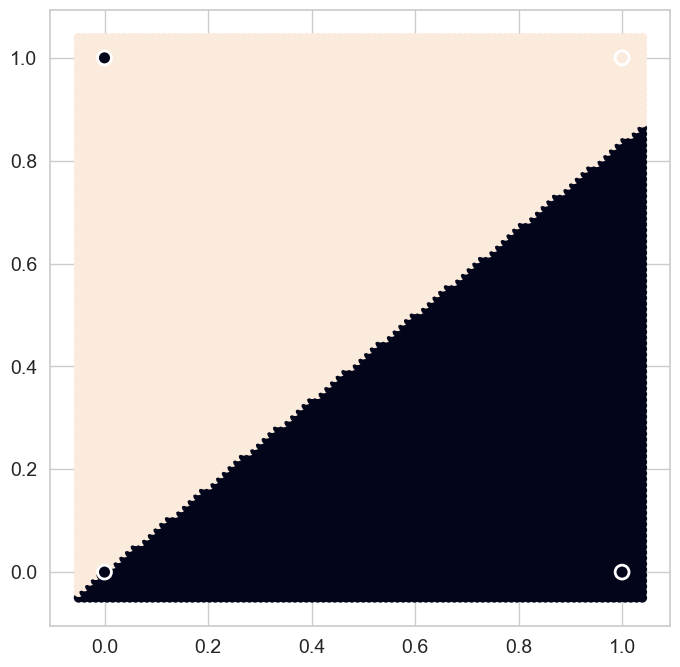

In [12]:
# test run of the initialization

mlp = MLP('sigmoid')
mse = torch.nn.MSELoss()

p = mlp.model(X)
l = mse(p, y)

print("Targets: {},\nPredictions: {},\nLoss {},\nAcc.: {}".format(y, p, l, (mlp.classify(X) == y).float().mean()))
torch_predict = lambda x: mlp.classify(torch.tensor(x, dtype=torch.float)).numpy() 
hp.plot_binary(torch_predict, X, y)

In [13]:
mlp = MLP('tanh')

@interact_manual(X = fixed(X), y=fixed(y), md=['sigmoid', 'tanh'], h=(0.1,0.5,0.1), epochs=(10,100,10))
def train(X, y, h = 0.1, md='tanh', epochs=50):   
    if mlp.m_select != md: mlp.setup(md)
    
    for epoch in range(epochs):
        p = mlp.model(X)
        l = mse(p, y)
        l.backward()

        # do not record updates for the gradient update
        with torch.no_grad():
            mlp.update_weights(h)

    print("Predictions: {},\nLoss {},\nAcc.: {}".format(p, l, (mlp.classify(X) == y).float().mean()))
    hp.plot_binary(torch_predict, X, y)

interactive(children=(FloatSlider(value=0.1, description='h', max=0.5, min=0.1), Dropdown(description='md', in…